# Measuring the Impact of the 2023 MLB Rule Changes
**DS-399 Major Capstone Project** · Meira Feltman · Instructor: Sharath Kumar Jagannathan · May–July 2026

Full analysis pipeline: EDA → Statistical Testing → OLS Regression → Bootstrap CIs → DiD → Placebo Test → Player Fixed Effects → Cross-Validated Models → Permutation Importance

## Setup & Data Loading

In [ ]:
# -*- coding: utf-8 -*-
"""
DS-399 Major Capstone Project
Measuring the Impact of the 2023 MLB Rule Changes

Description:
    Full analysis pipeline for the 2023 MLB rule changes capstone project.
    Covers EDA, statistical testing, OLS regression, cross-validated model
    comparison, bootstrap CIs, DiD regression, placebo tests, and player
    fixed-effects panel regression.

Datasets (loaded from Google Drive /ds399/data/clean/):
    - batting_clean.csv       (670 player-seasons, 25 features)
    - gamelogs_clean.csv      (~9,700 game-level records)
    - sprint_speed_clean.csv  (~2,900 player-season sprint records)

Outputs:
    - Figures saved to /ds399/figures/
    - CSV result tables saved to current working directory

Sections:
    0. Setup & Data Loading
    1. Pace of Play (H1)
    2. Stolen Bases (H2)
    3. Shift Ban — BABIP & Batting Average (H3)
    4. Strikeout & Walk Rate (H4)
    5. H3 Subgroup Analysis — Handedness Merge (LHB vs RHB)
    6. OLS Regression — Predicting BABIP
    7. OLS Regression — Predicting SB Success Rate
    8. Advanced Analysis (Bootstrap CIs, DiD, Placebo Test,
       Player Fixed Effects, Cross-Validated Models, Permutation Importance)
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

CLEAN_DIR = "/content/drive/MyDrive/ds399/data/clean"
FIG_DIR   = "/content/drive/MyDrive/ds399/figures"
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
SEASONS = [2021, 2022, 2023, 2024, 2025]

# ── Load all datasets once ────────────────────────────────────────────────────
batting  = pd.read_csv(os.path.join(CLEAN_DIR, "batting_clean.csv"))
gamelogs = pd.read_csv(os.path.join(CLEAN_DIR, "gamelogs_clean.csv"))
speed    = pd.read_csv(os.path.join(CLEAN_DIR, "sprint_speed_clean.csv"))

print(f"batting:  {batting.shape}")
print(f"gamelogs: {gamelogs.shape}")
print(f"speed:    {speed.shape}")

# ── Outlier removal (IQR method, applied per season) ─────────────────────────
def remove_outliers(df, col, group_col="season"):
    """Remove rows where col is outside 1.5*IQR within each season."""
    def iqr_filter(g):
        Q1, Q3 = g[col].quantile(0.25), g[col].quantile(0.75)
        IQR = Q3 - Q1
        return g[(g[col] >= Q1 - 1.5*IQR) & (g[col] <= Q3 + 1.5*IQR)]
    return df.groupby(group_col, group_keys=False).apply(iqr_filter)

# Apply outlier removal to each key metric
batting_clean  = remove_outliers(batting,  "avg")
batting_clean  = remove_outliers(batting_clean, "babip")
batting_clean  = remove_outliers(batting_clean, "k_pct")
batting_clean  = remove_outliers(batting_clean, "sb_attempt_rate")
gamelogs_clean = remove_outliers(gamelogs, "game_minutes")
sprint_speed_clean = remove_outliers(speed, "sprint_speed") # Added this line

print(f"\nAfter outlier removal:")
print(f"  batting:  {len(batting)} → {len(batting_clean)} rows")
print(f"  gamelogs: {len(gamelogs)} → {len(gamelogs_clean)} rows")

# ── Shared helpers ────────────────────────────────────────────────────────────
def save_fig(name):
    path = os.path.join(FIG_DIR, f"{name}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {path}")

def ttest_report(df, col, label):
    pre  = df[df["season"] == 2022][col].dropna()
    post = df[df["season"] == 2023][col].dropna()
    t, p = stats.ttest_ind(pre, post)
    d    = (post.mean() - pre.mean()) / ((pre.std() + post.std()) / 2)
    sig  = "✓ Significant (p < 0.05)" if p < 0.05 else "✗ Not significant"
    print(f"\n{label}: 2022 vs 2023")
    print(f"  2022: {pre.mean():.3f}  |  2023: {post.mean():.3f}  |  diff: {post.mean()-pre.mean():+.3f}")
    print(f"  t={t:.3f}, p={p:.3f}, Cohen's d={d:.3f}  →  {sig}")

print("\n✓ Setup complete. Run any analysis cell below.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
batting:  (670, 25)
gamelogs: (9714, 8)
speed:    (2874, 9)

After outlier removal:
  batting:  670 → 640 rows
  gamelogs: 9714 → 9532 rows

✓ Setup complete. Run any analysis cell below.


/tmp/ipykernel_1685/2529354718.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col, group_keys=False).apply(iqr_filter)
/tmp/ipykernel_1685/2529354718.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col, group_keys=False).apply(iqr_filter)
/tmp/ipykernel_1685/2529354718.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping column

## Section 1 — Pace of Play (H1)

 season       mean  median       std  games
   2021 190.420498   189.0 24.236909   2371
   2022 185.472467   184.0 21.093059   2379
   2023 161.480552   161.0 18.098439   2391
   2024 157.815558   156.0 17.311298   2391


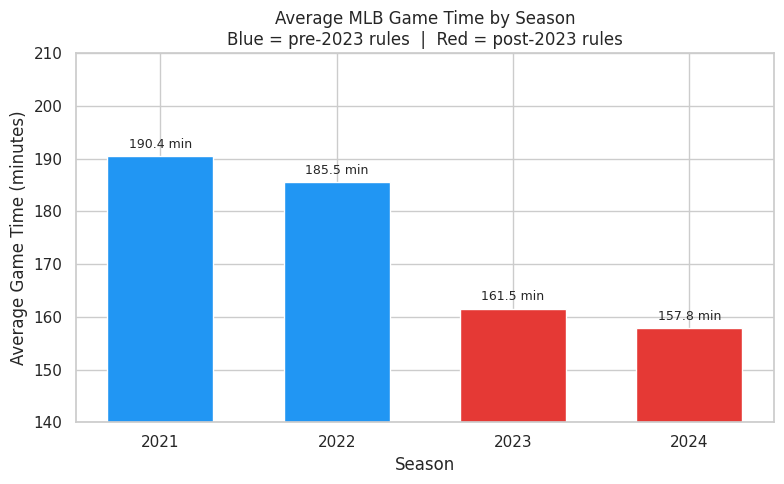

  Saved → /content/drive/MyDrive/ds399/figures/01a_game_time_bar.png


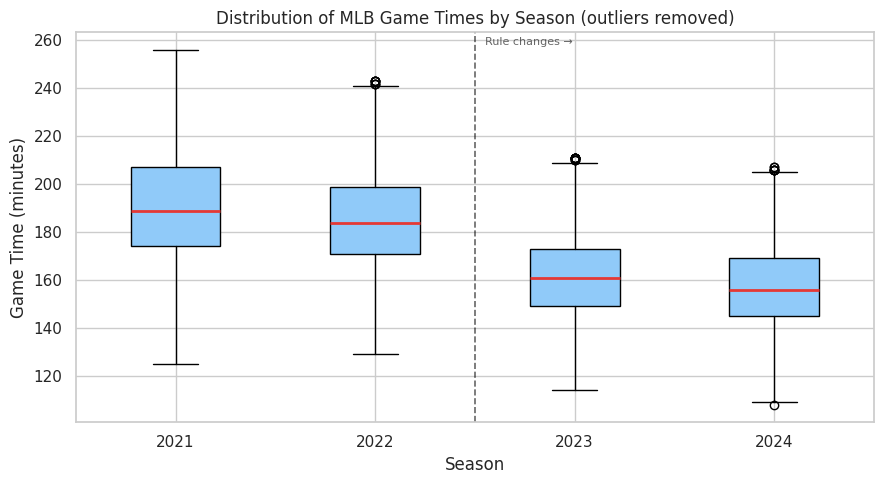

  Saved → /content/drive/MyDrive/ds399/figures/01b_game_time_boxplot.png

Game Time (minutes): 2022 vs 2023
  2022: 185.472  |  2023: 161.481  |  diff: -23.992
  t=42.165, p=0.000, Cohen's d=-1.224  →  ✓ Significant (p < 0.05)


In [ ]:
"""
### 1. Pace of Play
**Hypothesis:** Average game time decreased significantly since 2023 due to the pitch clock.
"""

COLORS_4 = ["#2196F3","#2196F3","#E53935","#E53935"]

pace = gamelogs_clean.groupby("season")["game_minutes"].agg(["mean","median","std","count"]).reset_index()
pace.columns = ["season","mean","median","std","games"]
print(pace.to_string(index=False))

# Fig 1: Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(pace["season"].astype(str), pace["mean"],
              color=COLORS_4, edgecolor="white", width=0.6)
ax.bar_label(bars, labels=[f"{v:.1f} min" for v in pace["mean"]], padding=4, fontsize=9)
ax.set_xlabel("Season")
ax.set_ylabel("Average Game Time (minutes)")
ax.set_title("Average MLB Game Time by Season\nBlue = pre-2023 rules  |  Red = post-2023 rules")
ax.set_ylim(140, 210)
plt.tight_layout()
save_fig("01a_game_time_bar")

# Fig 2: Box plot
fig, ax = plt.subplots(figsize=(9, 5))
gl_list = [gamelogs_clean[gamelogs_clean["season"] == y]["game_minutes"].dropna() for y in [2021,2022,2023,2024]]
ax.boxplot(gl_list, tick_labels=["2021","2022","2023","2024"],
           patch_artist=True,
           boxprops=dict(facecolor="#90CAF9"),
           medianprops=dict(color="#E53935", linewidth=2))
ax.axvline(x=2.5, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
ax.text(2.55, ax.get_ylim()[1] * 0.98, "Rule changes →", fontsize=8, alpha=0.7)
ax.set_xlabel("Season")
ax.set_ylabel("Game Time (minutes)")
ax.set_title("Distribution of MLB Game Times by Season (outliers removed)")
plt.tight_layout()
save_fig("01b_game_time_boxplot")

ttest_report(gamelogs_clean, "game_minutes", "Game Time (minutes)")

## Section 2 — Stolen Bases (H2)

 season  sb_total  cs_total  sb_rate_mean  success_rate
   2021       992       311      0.017372      0.761320
   2022      1055       310      0.018003      0.772894
   2023      1292       321      0.021674      0.800992
   2024      1395       361      0.023411      0.794419
   2025      1794       466      0.025725      0.793805


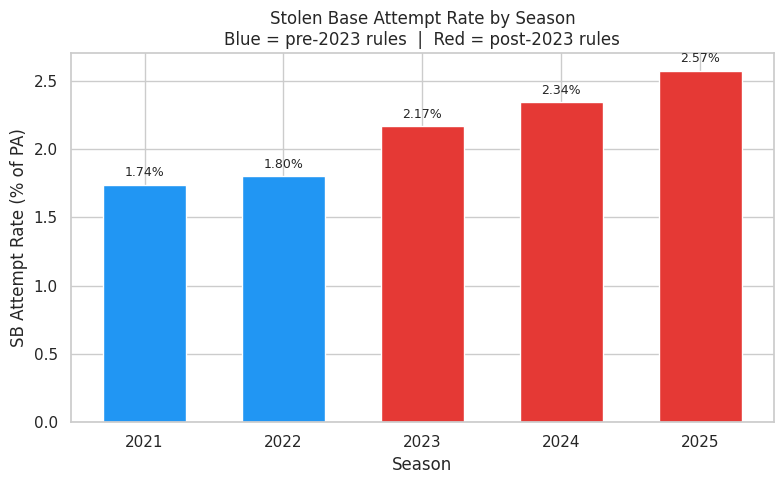

  Saved → /content/drive/MyDrive/ds399/figures/02a_sb_attempt_rate.png


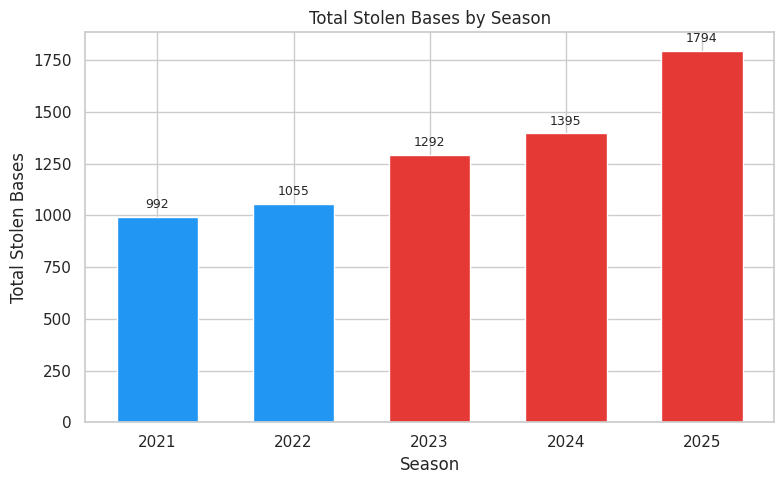

  Saved → /content/drive/MyDrive/ds399/figures/02b_total_sb.png


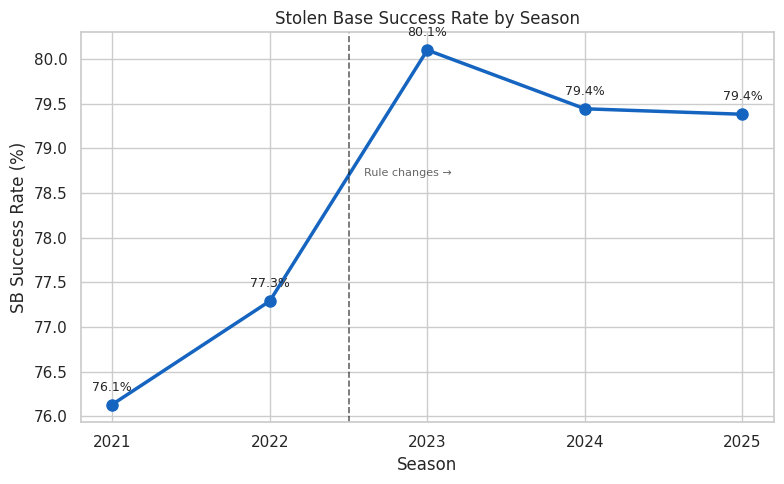

  Saved → /content/drive/MyDrive/ds399/figures/02c_sb_success_rate.png

SB Attempt Rate: 2022 vs 2023
  2022: 0.018  |  2023: 0.022  |  diff: +0.004
  t=-1.641, p=0.102, Cohen's d=0.209  →  ✗ Not significant


In [ ]:
"""
### 2. Stolen Bases
**Hypothesis:** SB attempt rates increased since 2023 due to larger bases.
"""

COLORS_5 = ["#2196F3","#2196F3","#E53935","#E53935","#E53935"]

sb = batting_clean.groupby("season").agg(
    sb_total      = ("sb", "sum"),
    cs_total      = ("cs", "sum"),
    sb_rate_mean  = ("sb_attempt_rate", "mean"),
).reset_index()
sb["success_rate"] = sb["sb_total"] / (sb["sb_total"] + sb["cs_total"])
print(sb.to_string(index=False))

# Fig 1: SB attempt rate
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sb["season"].astype(str), sb["sb_rate_mean"] * 100,
              color=COLORS_5, edgecolor="white", width=0.6)
ax.bar_label(bars, labels=[f"{v*100:.2f}%" for v in sb["sb_rate_mean"]], padding=4, fontsize=9)
ax.set_xlabel("Season")
ax.set_ylabel("SB Attempt Rate (% of PA)")
ax.set_title("Stolen Base Attempt Rate by Season\nBlue = pre-2023 rules  |  Red = post-2023 rules")
plt.tight_layout()
save_fig("02a_sb_attempt_rate")

# Fig 2: Total SBs
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sb["season"].astype(str), sb["sb_total"],
              color=COLORS_5, edgecolor="white", width=0.6)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel("Season")
ax.set_ylabel("Total Stolen Bases")
ax.set_title("Total Stolen Bases by Season")
plt.tight_layout()
save_fig("02b_total_sb")

# Fig 3: Success rate
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sb["season"], sb["success_rate"] * 100, marker="o", linewidth=2.5,
        color="#1565C0", markersize=8)
for _, row in sb.iterrows():
    ax.annotate(f"{row['success_rate']*100:.1f}%", (row["season"], row["success_rate"]*100),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
ax.axvline(x=2022.5, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
ax.text(2022.6, ax.get_ylim()[1] * 0.98, "Rule changes →", fontsize=8, alpha=0.7)
ax.set_xlabel("Season")
ax.set_ylabel("SB Success Rate (%)")
ax.set_title("Stolen Base Success Rate by Season")
ax.set_xticks(SEASONS)
plt.tight_layout()
save_fig("02c_sb_success_rate")

ttest_report(batting_clean, "sb_attempt_rate", "SB Attempt Rate")


## Section 3 — Shift Ban: BABIP & Batting Average (H3)

 season  avg_mean  avg_median  babip_mean  babip_median
   2021  0.264913      0.2650    0.302627         0.304
   2022  0.259063      0.2575    0.295524         0.295
   2023  0.260344      0.2615    0.302369         0.301
   2024  0.256870      0.2540    0.297707         0.299
   2025  0.257713      0.2570    0.295231         0.295


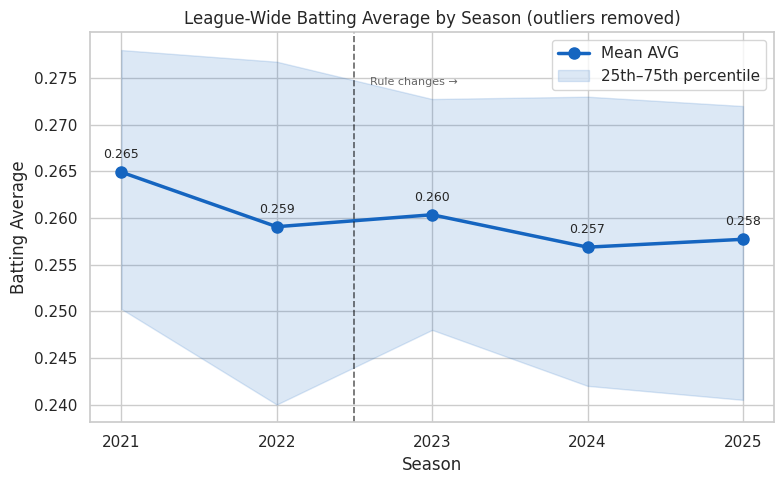

  Saved → /content/drive/MyDrive/ds399/figures/03a_batting_average.png


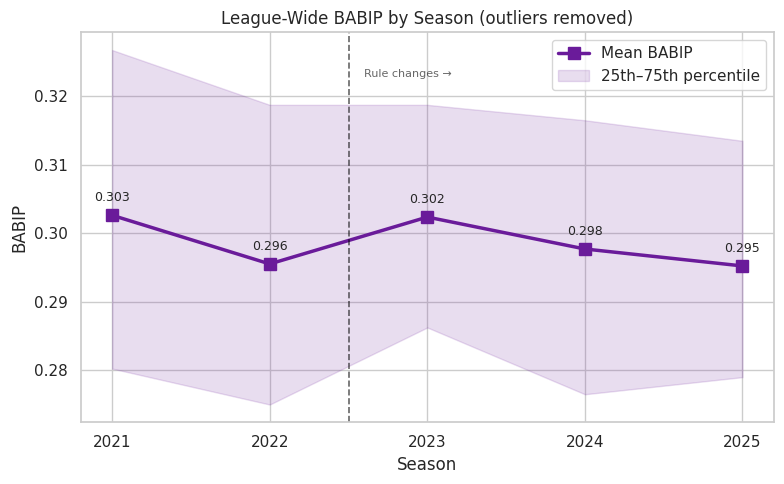

  Saved → /content/drive/MyDrive/ds399/figures/03b_babip.png


/tmp/ipykernel_1685/1661234720.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(y) for y in SEASONS],
/tmp/ipykernel_1685/1661234720.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(y) for y in SEASONS],


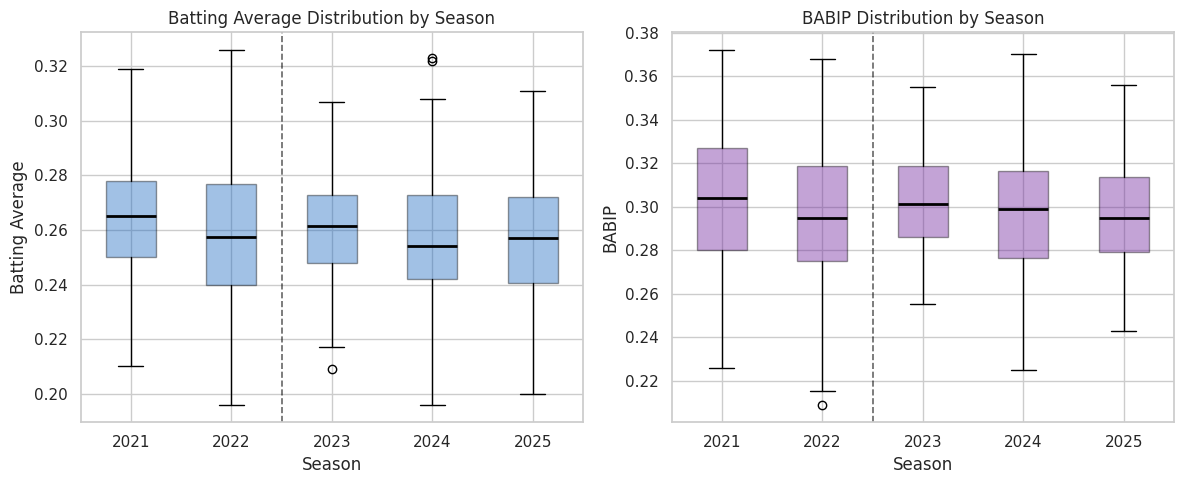

  Saved → /content/drive/MyDrive/ds399/figures/03c_avg_babip_boxplots.png

Batting Average: 2022 vs 2023
  2022: 0.259  |  2023: 0.260  |  diff: +0.001
  t=-0.423, p=0.673, Cohen's d=0.055  →  ✗ Not significant

BABIP: 2022 vs 2023
  2022: 0.296  |  2023: 0.302  |  diff: +0.007
  t=-1.861, p=0.064, Cohen's d=0.241  →  ✗ Not significant


In [ ]:
"""
### 3. Shift Ban — BABIP & Batting Average
**Hypothesis:** BABIP and AVG improved since 2023 for hitters previously shifted against.
"""

hit = batting_clean.groupby("season").agg(
    avg_mean   = ("avg",   "mean"),
    avg_median = ("avg",   "median"),
    babip_mean = ("babip", "mean"),
    babip_median=("babip", "median"),
).reset_index()
print(hit.to_string(index=False))

# Fig 1: AVG trend
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hit["season"], hit["avg_mean"], marker="o", linewidth=2.5,
        color="#1565C0", markersize=8, label="Mean AVG")
ax.fill_between(hit["season"],
                batting_clean.groupby("season")["avg"].quantile(0.25).values,
                batting_clean.groupby("season")["avg"].quantile(0.75).values,
                alpha=0.15, color="#1565C0", label="25th–75th percentile")
for _, row in hit.iterrows():
    ax.annotate(f"{row['avg_mean']:.3f}", (row["season"], row["avg_mean"]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
ax.axvline(x=2022.5, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
ax.text(2022.6, ax.get_ylim()[1] * 0.98, "Rule changes →", fontsize=8, alpha=0.7)
ax.set_xlabel("Season")
ax.set_ylabel("Batting Average")
ax.set_title("League-Wide Batting Average by Season (outliers removed)")
ax.set_xticks(SEASONS)
ax.legend()
plt.tight_layout()
save_fig("03a_batting_average")

# Fig 2: BABIP trend
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hit["season"], hit["babip_mean"], marker="s", linewidth=2.5,
        color="#6A1B9A", markersize=8, label="Mean BABIP")
ax.fill_between(hit["season"],
                batting_clean.groupby("season")["babip"].quantile(0.25).values,
                batting_clean.groupby("season")["babip"].quantile(0.75).values,
                alpha=0.15, color="#6A1B9A", label="25th–75th percentile")
for _, row in hit.iterrows():
    ax.annotate(f"{row['babip_mean']:.3f}", (row["season"], row["babip_mean"]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
ax.axvline(x=2022.5, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
ax.text(2022.6, ax.get_ylim()[1] * 0.98, "Rule changes →", fontsize=8, alpha=0.7)
ax.set_xlabel("Season")
ax.set_ylabel("BABIP")
ax.set_title("League-Wide BABIP by Season (outliers removed)")
ax.set_xticks(SEASONS)
ax.legend()
plt.tight_layout()
save_fig("03b_babip")

# Fig 3: Side-by-side box plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title, color in zip(axes, ["avg","babip"], ["Batting Average","BABIP"], ["#1565C0","#6A1B9A"]):
    data = [batting_clean[batting_clean["season"] == y][col].dropna() for y in SEASONS]
    ax.boxplot(data, labels=[str(y) for y in SEASONS],
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.4),
               medianprops=dict(color="black", linewidth=2))
    ax.axvline(x=2.5, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
    ax.set_xlabel("Season")
    ax.set_ylabel(title)
    ax.set_title(f"{title} Distribution by Season")
plt.tight_layout()
save_fig("03c_avg_babip_boxplots")

ttest_report(batting_clean, "avg",   "Batting Average")
ttest_report(batting_clean, "babip", "BABIP")



## Section 4 — Strikeout & Walk Rate (H4)

 season  k_pct_mean  k_pct_median  bb_pct_mean  bb_pct_median
   2021   20.648413         20.55     9.244444           9.15
   2022   19.735714         18.90     8.725397           8.65
   2023   20.990164         21.25     8.859836           8.60
   2024   21.149593         21.10     8.724390           8.50
   2025   20.523776         20.40     8.825874           8.70


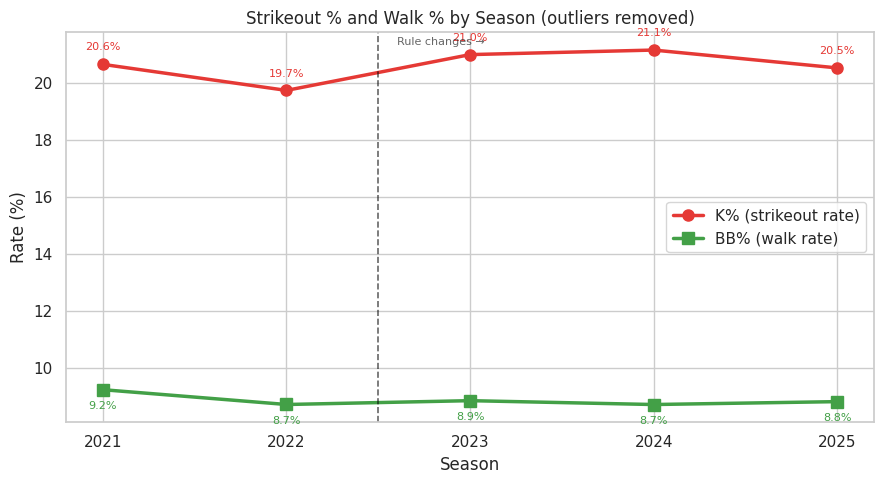

  Saved → /content/drive/MyDrive/ds399/figures/04a_k_bb_rate.png


/tmp/ipykernel_1685/222031038.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(y) for y in SEASONS],


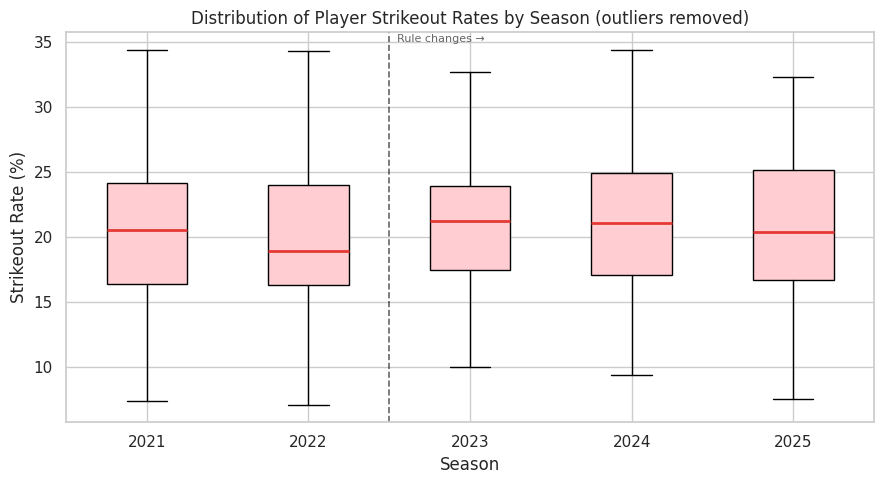

  Saved → /content/drive/MyDrive/ds399/figures/04b_k_pct_boxplot.png


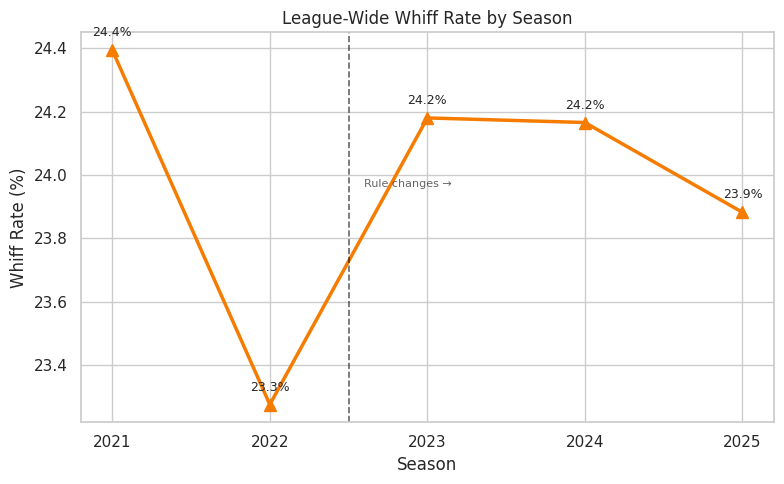

  Saved → /content/drive/MyDrive/ds399/figures/04c_whiff_rate.png

Strikeout Rate (K%): 2022 vs 2023
  2022: 19.736  |  2023: 20.990  |  diff: +1.254
  t=-1.937, p=0.054, Cohen's d=0.246  →  ✗ Not significant

Walk Rate (BB%): 2022 vs 2023
  2022: 8.725  |  2023: 8.860  |  diff: +0.134
  t=-0.369, p=0.713, Cohen's d=0.047  →  ✗ Not significant


CompletedProcess(args=['pip', 'install', 'pybaseball', '-q'], returncode=0)

In [ ]:
"""
### 4. Strikeout Rate
**Hypothesis:** K% declined slightly since 2023 as the pitch clock limits pitcher reset time.
"""

ks = batting_clean.groupby("season").agg(
    k_pct_mean   = ("k_pct",  "mean"),
    k_pct_median = ("k_pct",  "median"),
    bb_pct_mean  = ("bb_pct", "mean"),
    bb_pct_median= ("bb_pct", "median"),
).reset_index()
print(ks.to_string(index=False))

# Fig 1: K% and BB% dual line
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ks["season"], ks["k_pct_mean"], marker="o", linewidth=2.5,
        color="#E53935", markersize=8, label="K% (strikeout rate)")
ax.plot(ks["season"], ks["bb_pct_mean"], marker="s", linewidth=2.5,
        color="#43A047", markersize=8, label="BB% (walk rate)")
for _, row in ks.iterrows():
    ax.annotate(f"{row['k_pct_mean']:.1f}%", (row["season"], row["k_pct_mean"]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8, color="#E53935")
    ax.annotate(f"{row['bb_pct_mean']:.1f}%", (row["season"], row["bb_pct_mean"]),
                textcoords="offset points", xytext=(0, -14), ha="center", fontsize=8, color="#43A047")
ax.axvline(x=2022.5, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
ax.text(2022.6, ax.get_ylim()[1] * 0.98, "Rule changes →", fontsize=8, alpha=0.7)
ax.set_xlabel("Season")
ax.set_ylabel("Rate (%)")
ax.set_title("Strikeout % and Walk % by Season (outliers removed)")
ax.set_xticks(SEASONS)
ax.legend()
plt.tight_layout()
save_fig("04a_k_bb_rate")

# Fig 2: K% box plot
fig, ax = plt.subplots(figsize=(9, 5))
data = [batting_clean[batting_clean["season"] == y]["k_pct"].dropna() for y in SEASONS]
ax.boxplot(data, labels=[str(y) for y in SEASONS],
           patch_artist=True,
           boxprops=dict(facecolor="#FFCDD2"),
           medianprops=dict(color="#E53935", linewidth=2))
ax.axvline(x=2.5, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
ax.text(2.55, ax.get_ylim()[1] * 0.98, "Rule changes →", fontsize=8, alpha=0.7)
ax.set_xlabel("Season")
ax.set_ylabel("Strikeout Rate (%)")
ax.set_title("Distribution of Player Strikeout Rates by Season (outliers removed)")
plt.tight_layout()
save_fig("04b_k_pct_boxplot")

# Fig 3: Whiff rate
if "whiff_pct" in batting_clean.columns:
    whiff = batting_clean.groupby("season")["whiff_pct"].mean().reset_index()
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(whiff["season"], whiff["whiff_pct"], marker="^", linewidth=2.5,
            color="#F57C00", markersize=8)
    for _, row in whiff.iterrows():
        ax.annotate(f"{row['whiff_pct']:.1f}%", (row["season"], row["whiff_pct"]),
                    textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
    ax.axvline(x=2022.5, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
    ax.text(2022.6, ax.get_ylim()[1] * 0.98, "Rule changes →", fontsize=8, alpha=0.7)
    ax.set_xlabel("Season")
    ax.set_ylabel("Whiff Rate (%)")
    ax.set_title("League-Wide Whiff Rate by Season")
    ax.set_xticks(SEASONS)
    plt.tight_layout()
    save_fig("04c_whiff_rate")

ttest_report(batting_clean, "k_pct",  "Strikeout Rate (K%)")
ttest_report(batting_clean, "bb_pct", "Walk Rate (BB%)")

import subprocess
subprocess.run(["pip", "install", "pybaseball", "-q"])




## Section 5 — H3 Subgroup Analysis: LHB vs RHB Handedness Merge

In [ ]:
"""
H3 Subgroup Analysis — Fixed Handedness Merge
DS-399 Major Capstone Project — Meira Feltman

Fixes two problems from the previous attempt:
  1. Statcast was pulling pitchers — now filters to PA-ending events only
  2. Merges on player_id (MLB batter ID) instead of name, which is exact
batting_clean already has player_id — Statcast has 'batter' (same MLB ID).
"""

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pybaseball import statcast
from pybaseball import cache
cache.enable()
import os # Import os module if not already present

# ── 1. Load batting_clean ────────────────────────────────────────────────────
batting_clean = pd.read_csv(os.path.join(CLEAN_DIR, "batting_clean.csv")) # Corrected path
print(f"batting_clean: {batting_clean.shape}")
print(f"player_id sample: {batting_clean['player_id'].head(5).tolist()}")

# ── 2. Pull one week of Statcast per season, filter to batters only ──────────
# PA-ending events = rows where 'events' is not null.
# Each such row has: batter (MLB ID), stand (L/R/S)

SEASON_WEEKS = {
    2021: ("2021-04-01", "2021-04-07"),
    2022: ("2022-04-07", "2022-04-13"),
    2023: ("2023-03-30", "2023-04-05"),
    2024: ("2024-03-20", "2024-03-26"),
    2025: ("2025-03-27", "2025-04-02"),
}

hand_frames = []

for season, (start, end) in SEASON_WEEKS.items():
    print(f"\nFetching {season} ({start} → {end}) ...")
    try:
        df = statcast(start_dt=start, end_dt=end)
        if df is None or df.empty:
            print(f"  WARNING: no data for {season}")
            continue

        # Filter to plate appearance outcomes only (excludes pitcher-only rows)
        pa_df = df[df["events"].notna()][["batter", "stand"]].dropna()
        pa_df = pa_df.drop_duplicates(subset="batter")
        pa_df["season"] = season
        pa_df = pa_df.rename(columns={"batter": "player_id"})
        hand_frames.append(pa_df)
        print(f"  → {len(pa_df)} unique batters | stand: {pa_df['stand'].value_counts().to_dict()}")

    except Exception as e:
        print(f"  ERROR: {e}")

hand_df = pd.concat(hand_frames, ignore_index=True)
print(f"\nFull handedness table: {hand_df.shape}")

# ── 3. Merge on player_id + season ───────────────────────────────────────────
# Ensure types match (both should be int, but worth checking)
batting_clean["player_id"] = batting_clean["player_id"].astype(int)
hand_df["player_id"]       = hand_df["player_id"].astype(int)

batting_with_hand = batting_clean.merge(hand_df, on=["player_id", "season"], how="left")

total   = len(batting_with_hand)
matched = batting_with_hand["stand"].notna().sum()
print(f"\nMerge result: {matched}/{total} matched ({matched/total:.0%})")

# Fallback: if a player appears in any season's lookup, use that stand value
# (handedness never changes — switch hitters are coded S throughout)
if matched / total < 0.90:
    print("Applying season-agnostic fallback for unmatched rows...")
    id_to_stand = (
        hand_df.groupby("player_id")["stand"]
        .agg(lambda x: x.mode()[0])
        .reset_index()
    )
    unmatched = batting_with_hand["stand"].isna()
    fallback  = batting_with_hand.loc[unmatched, "player_id"].map(
        id_to_stand.set_index("player_id")["stand"]
    )
    batting_with_hand.loc[unmatched, "stand"] = fallback
    matched2 = batting_with_hand["stand"].notna().sum()
    print(f"After fallback: {matched2}/{total} matched ({matched2/total:.0%})")

print("\nStand distribution after merge:")
print(batting_with_hand["stand"].value_counts())

# ── 4. Subgroup filter ────────────────────────────────────────────────────────
lhb = batting_with_hand[batting_with_hand["stand"] == "L"].copy()
rhb = batting_with_hand[batting_with_hand["stand"] == "R"].copy()
print(f"\nLHB rows: {len(lhb)} | RHB rows: {len(rhb)}")
print("\nLHB by season:")
print(lhb["season"].value_counts().sort_index())

# ── 5. Descriptive stats ──────────────────────────────────────────────────────
def season_summary(df, label):
    tbl = df.groupby("season").agg(
        N        = ("avg",   "count"),
        avg_mean = ("avg",   "mean"),
        avg_med  = ("avg",   "median"),
        bap_mean = ("babip", "mean"),
        bap_med  = ("babip", "median"),
    ).round(4)
    print(f"\n── {label} ──")
    print(tbl.to_string())
    return tbl

lhb_summary = season_summary(lhb, "Left-Handed Batters by Season")
rhb_summary = season_summary(rhb, "Right-Handed Batters by Season")

# ── 6. Statistical tests: 2022 vs 2023 ───────────────────────────────────────
def ttest_report(df, col, label):
    pre  = df[df["season"] == 2022][col].dropna()
    post = df[df["season"] == 2023][col].dropna()
    if len(pre) < 5 or len(post) < 5:
        print(f"\n  {label}: insufficient data (n_2022={len(pre)}, n_2023={len(post)})")
        return None
    t, p = stats.ttest_ind(pre, post)
    d    = (post.mean() - pre.mean()) / ((pre.std() + post.std()) / 2)
    sig  = "SIGNIFICANT (p < 0.05)" if p < 0.05 else "not significant"
    print(f"\n  {label}")
    print(f"    Mean 2022: {pre.mean():.4f}  |  Mean 2023: {post.mean():.4f}  |  Diff: {post.mean()-pre.mean():+.4f}")
    print(f"    n 2022={len(pre)}, n 2023={len(post)}")
    print(f"    t = {t:.3f},  p = {p:.4f},  Cohen's d = {d:.3f}")
    print(f"    → {sig}")
    return {"label": label, "col": col,
            "mean_2022": pre.mean(), "mean_2023": post.mean(),
            "diff": post.mean()-pre.mean(),
            "t": t, "p": p, "cohens_d": d,
            "n_2022": len(pre), "n_2023": len(post)}

print("\n══ Statistical Tests: 2022 vs 2023 ══")
r1 = ttest_report(lhb, "babip", "BABIP — Left-Handed Batters")
r2 = ttest_report(lhb, "avg",   "AVG   — Left-Handed Batters")
r3 = ttest_report(rhb, "babip", "BABIP — Right-Handed Batters")
r4 = ttest_report(rhb, "avg",   "AVG   — Right-Handed Batters")

# ── 7. Difference-in-Differences ─────────────────────────────────────────────
print("\n══ Difference-in-Differences (LHB vs RHB, 2022→2023) ══")
for metric in ["babip", "avg"]:
    lhb_chg = lhb[lhb["season"]==2023][metric].mean() - lhb[lhb["season"]==2022][metric].mean()
    rhb_chg = rhb[rhb["season"]==2023][metric].mean() - rhb[rhb["season"]==2022][metric].mean()
    did     = lhb_chg - rhb_chg
    print(f"\n  {metric.upper()}:")
    print(f"    LHB 2022→2023: {lhb_chg:+.4f}")
    print(f"    RHB 2022→2023: {rhb_chg:+.4f}")
    print(f"    DiD:           {did:+.4f}  ← shift-ban-specific effect on LHB")

# ── 8. Chart ──────────────────────────────────────────────────────────────────
SEASONS = sorted(batting_with_hand["season"].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("H3 Shift Ban: BABIP & AVG by Batter Handedness (2021–2025)",
             fontsize=13, fontweight="bold")

for ax, metric, ylabel in zip(
    axes,
    ["babip", "avg"],
    ["BABIP", "Batting Average"]
):
    for hand, label, color in [("L", "Left-Handed",  "#2E75B6"),
                                ("R", "Right-Handed", "#C0392B")]:
        sub   = batting_with_hand[batting_with_hand["stand"] == hand]
        means = [sub[sub["season"] == s][metric].mean() for s in SEASONS]
        ax.plot(SEASONS, means, marker="o", color=color,
                label=label, linewidth=2.2, markersize=7)
        for s, m in zip(SEASONS, means):
            if not np.isnan(m):
                ax.annotate(f"{m:.3f}", (s, m),
                            textcoords="offset points", xytext=(0, 9),
                            ha="center", fontsize=8, color=color)

    ax.axvline(x=2022.5, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
    ax.text(2022.6, ax.get_ylim()[1] * 0.995,
            "2023 rules →", fontsize=8, alpha=0.65, va="top")
    ax.set_title(ylabel, fontweight="bold")
    ax.set_xlabel("Season")
    ax.set_ylabel(ylabel)
    ax.set_xticks(SEASONS)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("04_lhb_shift_ban.png", dpi=150, bbox_inches="tight")
print("\nChart saved: 04_lhb_shift_ban.png")
plt.show()


batting_clean: (670, 25)
player_id sample: [408234, 443558, 444482, 453568, 457705]

Fetching 2021 (2021-04-01 → 2021-04-07) ...
This is a large query, it may take a moment to complete


  0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
 14%|█▍        | 1/7 [00:03<00:23,  3.88s/it]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exception

  → 470 unique batters | stand: {'R': 288, 'L': 182}

Fetching 2022 (2022-04-07 → 2022-04-13) ...
This is a large query, it may take a moment to complete


  0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = da

  → 396 unique batters | stand: {'R': 238, 'L': 158}

Fetching 2023 (2023-03-30 → 2023-04-05) ...
This is a large query, it may take a moment to complete


...

  → 394 unique batters | stand: {'R': 228, 'L': 166}

Fetching 2024 (2024-03-20 → 2024-03-26) ...
This is a large query, it may take a moment to complete


  0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
 14%|█▍        | 1/7 [00:03<00:22,  3.70s/it]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exception

  → 1116 unique batters | stand: {'R': 649, 'L': 467}

Fetching 2025 (2025-03-27 → 2025-04-02) ...
This is a large query, it may take a moment to complete


  0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = da

  → 398 unique batters | stand: {'R': 240, 'L': 158}

Full handedness table: (2774, 3)

Merge result: 646/670 matched (96%)

Stand distribution after merge:
stand
R    384
L    262
Name: count, dtype: int64

LHB rows: 262 | RHB rows: 384

LHB by season:
season
2021    51
2022    41
2023    53
2024    55
2025    62
Name: count, dtype: int64

── Left-Handed Batters by Season ──
         N  avg_mean  avg_med  bap_mean  bap_med
season                                          
2021    51    0.2643   0.2660    0.3007    0.306
2022    41    0.2562   0.2460    0.2887    0.276
2023    53    0.2628   0.2620    0.2993    0.299
2024    55    0.2601   0.2560    0.2973    0.300
2025    62    0.2584   0.2585    0.2966    0.293

── Right-Handed Batters by Season ──
         N  avg_mean  avg_med  bap_mean  bap_med
season                                          
2021    77    0.2654   0.2650    0.3044   0.3010
2022    84    0.2592   0.2590    0.2982   0.2955
2023    75    0.2603   0.2610    0.3022   0.

## Section 6 — OLS Regression: Predicting BABIP

In [ ]:
# BABIP Predictive Model (OLS Regression)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# ── Step 1: Prepare the dataset ───────────────────────────────────
# Use batting_with_hand if you completed the handedness merge,
# otherwise use batting_clean and drop the stand column below

df = batting_with_hand.copy()  # swap to batting_clean if handedness not available

# Encode handedness: L = 1, R = 0
df["is_lhb"] = (df["stand"] == "L").astype(int)

# Select features and target
features = ["k_pct", "bb_pct", "slg", "sb_attempt_rate", "post_rules", "is_lhb"]
target   = "babip"

# Drop rows with missing values in any feature or target
model_df = df[features + [target]].dropna()
print(f"Model dataset: {len(model_df)} rows after dropping NAs")

# ── Step 2: Train/test split ──────────────────────────────────────
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

# ── Step 3: OLS Regression (statsmodels for full summary) ────────
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train_sm).fit()
print("\n", model.summary())

# ── Step 4: Evaluate on test set ─────────────────────────────────
y_pred = model.predict(X_test_sm)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest Set Results:")
print(f"  R-squared : {r2:.4f}")
print(f"  RMSE      : {rmse:.4f}")

# ── Step 5: Coefficient plot ──────────────────────────────────────
coefs = model.params.drop("const")
errors = model.bse.drop("const")
pvals = model.pvalues.drop("const")

colors = ["#E53935" if p < 0.05 else "#AAAAAA" for p in pvals]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coefs.index, coefs.values, xerr=1.96 * errors.values,
        color=colors, capsize=4, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Coefficient (effect on BABIP)")
ax.set_title("OLS Regression: Predictors of BABIP\n(red = significant at p < 0.05)")

labels = {
    "k_pct":           "Strikeout Rate",
    "bb_pct":          "Walk Rate",
    "slg":             "Slugging %",
    "sb_attempt_rate": "SB Attempt Rate",
    "post_rules":      "Post-2023 Rules",
    "is_lhb":          "Left-Handed Batter"
}
ax.set_yticklabels([labels.get(t.get_text(), t.get_text())
                    for t in ax.get_yticklabels()])

plt.tight_layout()
save_fig("05_babip_ols_coefficients")

# ── Step 6: Actual vs Predicted plot ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.5, color="#2E75B6", edgecolors="white", s=40)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual BABIP")
ax.set_ylabel("Predicted BABIP")
ax.set_title(f"Actual vs. Predicted BABIP (Test Set)\nR² = {r2:.3f}, RMSE = {rmse:.4f}")
ax.legend()
plt.tight_layout()
save_fig("05_babip_actual_vs_predicted")

# ── Step 7: Residual plot ─────────────────────────────────────────
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred, residuals, alpha=0.5, color="#2E75B6", edgecolors="white", s=40)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Predicted BABIP")
ax.set_ylabel("Residuals")
ax.set_title("Residual Plot — BABIP OLS Model")
plt.tight_layout()
save_fig("05_babip_residuals")

print("\nDone! Charts saved to your output folder.")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error



Model dataset: 670 rows after dropping NAs
Train: 536 rows | Test: 134 rows

                             OLS Regression Results                            
Dep. Variable:                  babip   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     16.63
Date:                Sun, 19 Jul 2026   Prob (F-statistic):           1.31e-17
Time:                        05:08:19   Log-Likelihood:                 1160.7
No. Observations:                 536   AIC:                            -2307.
Df Residuals:                     529   BIC:                            -2277.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

/tmp/ipykernel_1685/1500621455.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([labels.get(t.get_text(), t.get_text())


  Saved → /content/drive/MyDrive/ds399/figures/05_babip_ols_coefficients.png
  Saved → /content/drive/MyDrive/ds399/figures/05_babip_actual_vs_predicted.png
  Saved → /content/drive/MyDrive/ds399/figures/05_babip_residuals.png

Done! Charts saved to your output folder.


## Section 7 — OLS Regression: Predicting SB Success Rate

In [ ]:
# ── Step 1: Build target variable ─────────────────────────────────
df = batting_clean.copy()

# Calculate success rate: sb / (sb + cs)
# Only keep players who attempted at least 5 steals to avoid noise
df["sb_attempts"] = df["sb"] + df["cs"]
df = df[df["sb_attempts"] >= 5].copy()
df["sb_success_rate"] = df["sb"] / df["sb_attempts"]

print(f"Rows after filtering to 5+ attempts: {len(df)}")
print(f"\nSB success rate by season:")
print(df.groupby("season")["sb_success_rate"].agg(["mean","median","count"]).round(3))

# ── Step 2: Merge sprint speed ────────────────────────────────────
sprint_merge = sprint_speed_clean[["player_id","season","sprint_speed"]].copy()
df = df.merge(sprint_merge, on=["player_id","season"], how="left")

matched = df["sprint_speed"].notna().sum()
print(f"\nSprint speed merge: {matched}/{len(df)} rows matched ({matched/len(df):.0%})")

# ── Step 3: Features ──────────────────────────────────────────────
features = [
    "sprint_speed",      # speed is the primary driver of SB success
    "sb_attempt_rate",   # how often they attempt — reflects confidence/strategy
    "post_rules",        # did larger bases change success rates?
    "k_pct",             # contact hitters may read pitchers better
    "bb_pct",            # patient hitters may get better reads
]
target = "sb_success_rate"

model_df = df[features + [target]].dropna()
print(f"\nModel dataset: {len(model_df)} rows after dropping NAs")

# ── Step 4: Train/test split ──────────────────────────────────────
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── Step 5: OLS Regression ────────────────────────────────────────
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train_sm).fit()
print("\n", model.summary())

# ── Step 6: Test set evaluation ───────────────────────────────────
y_pred = model.predict(X_test_sm)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n=== SB Success Rate Model — Test Results ===")
print(f"  R-squared : {r2:.4f}")
print(f"  RMSE      : {rmse:.4f}")

# ── Step 7: Coefficient plot ──────────────────────────────────────
coefs  = model.params.drop("const")
errors = model.bse.drop("const")
pvals  = model.pvalues.drop("const")
colors = ["#E53935" if p < 0.05 else "#AAAAAA" for p in pvals]

labels = {
    "sprint_speed":     "Sprint speed",
    "sb_attempt_rate":  "SB attempt rate",
    "post_rules":       "Post-2023 rules",
    "k_pct":            "Strikeout rate",
    "bb_pct":           "Walk rate",
}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    [labels.get(c, c) for c in coefs.index],
    coefs.values,
    xerr=1.96 * errors.values,
    color=colors, capsize=4, edgecolor="white"
)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Coefficient (effect on SB success rate)")
ax.set_title(
    f"OLS Regression: Predictors of Stolen Base Success Rate\n"
    f"(red = significant p < 0.05 · R\u00b2 = {r2:.3f} · RMSE = {rmse:.4f})"
)
plt.tight_layout()
save_fig("07_sb_success_ols_coefficients")

# ── Step 8: Actual vs predicted ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.5, color="#2E75B6", edgecolors="white", s=50)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual SB success rate")
ax.set_ylabel("Predicted SB success rate")
ax.set_title(f"Actual vs. Predicted SB Success Rate\nR\u00b2 = {r2:.3f}, RMSE = {rmse:.4f}")
ax.legend()
plt.tight_layout()
save_fig("07_sb_success_actual_vs_predicted")

# ── Step 9: Success rate by season (context plot) ─────────────────
season_means = df.groupby("season")["sb_success_rate"].mean()
fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ["#2E75B6" if s >= 2023 else "#B5D4F4" for s in season_means.index]
ax.bar(season_means.index.astype(str), season_means.values,
       color=colors_bar, edgecolor="white")
for i, (s, v) in enumerate(season_means.items()):
    ax.annotate(f"{v:.1%}", (str(s), v),
                textcoords="offset points", xytext=(0, 6),
                ha="center", fontsize=10)
ax.axvline(1.5, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.text(1.6, season_means.max() * 0.98, "Rule changes →", fontsize=9, color="gray")
ax.set_xlabel("Season")
ax.set_ylabel("Avg SB success rate")
ax.set_title("Average Stolen Base Success Rate by Season\n(players with 5+ attempts · blue = post-2023 rules)")
ax.set_ylim(0, 1)
plt.tight_layout()
save_fig("07_sb_success_by_season")

print("\nDone! 3 charts saved.")

# ══════════════════════════════════════════════════════════════════════════════


Rows after filtering to 5+ attempts: 480

SB success rate by season:
         mean  median  count
season                      
2021    0.753   0.769     87
2022    0.755   0.780     86
2023    0.796   0.824     95
2024    0.776   0.804     96
2025    0.774   0.800    116

Sprint speed merge: 480/480 rows matched (100%)

Model dataset: 480 rows after dropping NAs
Train: 384 | Test: 96

                             OLS Regression Results                            
Dep. Variable:        sb_success_rate   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     6.734
Date:                Sun, 19 Jul 2026   Prob (F-statistic):           4.99e-06
Time:                        05:08:25   Log-Likelihood:                 261.02
No. Observations:                 384   AIC:                            -510.0
Df Residuals:                     378   BIC:              

## Section 8 — Advanced Analysis
Bootstrap CIs · DiD Regression · Placebo Test · Player Fixed Effects · Cross-Validated Models · Permutation Importance

In [ ]:
# SECTION 8: ADVANCED ANALYSIS
# Bootstrap CIs · Difference-in-Differences · Placebo Test ·
# Player Fixed Effects · Cross-Validated Models · Permutation Importance
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.formula.api as smf
import statsmodels.api as sm

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Helper functions

def ensure_post_rules(df):
    df = df.copy()
    if "post_rules" not in df.columns:
        df["post_rules"] = (df["season"] >= 2023).astype(int)
    return df

def cohens_d(pre, post):
    pre = pd.Series(pre).dropna()
    post = pd.Series(post).dropna()
    pooled = np.sqrt(((pre.std() ** 2) + (post.std() ** 2)) / 2)
    return (post.mean() - pre.mean()) / pooled if pooled != 0 else np.nan

def bootstrap_mean_diff(df, col, pre_season=2022, post_season=2023, n_boot=5000):
    pre = df[df["season"] == pre_season][col].dropna().values
    post = df[df["season"] == post_season][col].dropna().values

    diffs = []

    for _ in range(n_boot):
        pre_s = np.random.choice(pre, size=len(pre), replace=True)
        post_s = np.random.choice(post, size=len(post), replace=True)
        diffs.append(post_s.mean() - pre_s.mean())

    diffs = np.array(diffs)

    return {
        "metric": col,
        "pre_season": pre_season,
        "post_season": post_season,
        "mean_pre": pre.mean(),
        "mean_post": post.mean(),
        "mean_diff": post.mean() - pre.mean(),
        "bootstrap_ci_low": np.percentile(diffs, 2.5),
        "bootstrap_ci_high": np.percentile(diffs, 97.5),
        "cohens_d": cohens_d(pre, post)
    }

def safe_save(name):
    try:
        save_fig(name)
    except Exception:
        plt.savefig(f"{name}.png", dpi=150, bbox_inches="tight")
        plt.show()

# Prepare data
batting_clean = ensure_post_rules(batting_clean)
gamelogs_clean = ensure_post_rules(gamelogs_clean)

if "batting_with_hand" in globals():
    batting_model = ensure_post_rules(batting_with_hand.copy())
else:
    batting_model = ensure_post_rules(batting_clean.copy())

if "stand" not in batting_model.columns:
    batting_model["stand"] = np.nan

batting_model["is_lhb"] = (batting_model["stand"] == "L").astype(int)
batting_model["is_rhb"] = (batting_model["stand"] == "R").astype(int)

# 1. BOOTSTRAP CONFIDENCE INTERVALS FOR MAIN RULE EFFECTS

bootstrap_rows = []

bootstrap_specs = [
    (gamelogs_clean, "game_minutes", "Pitch Clock / Game Time"),
    (batting_clean, "sb_attempt_rate", "Larger Bases / SB Attempt Rate"),
    (batting_clean, "avg", "Shift Ban / Batting Average"),
    (batting_clean, "babip", "Shift Ban / BABIP"),
    (batting_clean, "k_pct", "Pitch Clock / Strikeout Rate"),
    (batting_clean, "bb_pct", "Pitch Clock / Walk Rate")
]

for df_temp, col, label in bootstrap_specs:
    if col in df_temp.columns:
        row = bootstrap_mean_diff(df_temp, col)
        row["hypothesis_area"] = label
        bootstrap_rows.append(row)

bootstrap_results = pd.DataFrame(bootstrap_rows)
print("BOOTSTRAP CONFIDENCE INTERVALS: 2022 VS 2023")
print(bootstrap_results.round(5).to_string(index=False))

bootstrap_results.to_csv("mlb_bootstrap_rule_effects.csv", index=False)

# Plot bootstrap effect sizes
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = bootstrap_results.copy()
plot_df["metric_label"] = plot_df["hypothesis_area"] + "\n(" + plot_df["metric"] + ")"

ax.errorbar(
    plot_df["mean_diff"],
    plot_df["metric_label"],
    xerr=[
        plot_df["mean_diff"] - plot_df["bootstrap_ci_low"],
        plot_df["bootstrap_ci_high"] - plot_df["mean_diff"]
    ],
    fmt="o",
    capsize=4
)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Bootstrap 95% Confidence Intervals for Rule-Change Effects")
ax.set_xlabel("Mean Difference: 2023 minus 2022")
ax.set_ylabel("Metric")
plt.tight_layout()
safe_save("08_bootstrap_rule_effects")

# 2. DIFFERENCE-IN-DIFFERENCES REGRESSION FOR SHIFT BAN
#    LHB vs RHB, 2022 to 2023

did_df = batting_model[
    batting_model["season"].isin([2022, 2023]) &
    batting_model["stand"].isin(["L", "R"])
].copy()

did_df["post_2023"] = (did_df["season"] == 2023).astype(int)
did_df["lhb"] = (did_df["stand"] == "L").astype(int)
did_df["lhb_x_post"] = did_df["lhb"] * did_df["post_2023"]

did_results = []

for target in ["babip", "avg"]:
    if target in did_df.columns:
        formula = f"{target} ~ post_2023 + lhb + lhb_x_post"
        model = smf.ols(formula, data=did_df).fit(cov_type="HC3")

        did_results.append({
            "target": target,
            "post_2023_coef": model.params.get("post_2023", np.nan),
            "lhb_coef": model.params.get("lhb", np.nan),
            "did_lhb_x_post_coef": model.params.get("lhb_x_post", np.nan),
            "did_p_value": model.pvalues.get("lhb_x_post", np.nan),
            "r_squared": model.rsquared,
            "n": int(model.nobs)
        })
        print(f"DIFFERENCE-IN-DIFFERENCES MODEL: {target.upper()}")
        print(model.summary())

did_results_df = pd.DataFrame(did_results)
print("DID SUMMARY: LHB-SPECIFIC SHIFT BAN EFFECT")
print(did_results_df.round(5).to_string(index=False))

did_results_df.to_csv("mlb_did_shift_ban_results.csv", index=False)

# 3. PLACEBO TEST
#    Pretend the rule change happened in 2022 instead of 2023.
#    Compare 2021 vs 2022.

placebo_rows = []

placebo_specs = [
    (gamelogs_clean, "game_minutes", "Pitch Clock / Game Time"),
    (batting_clean, "sb_attempt_rate", "Larger Bases / SB Attempt Rate"),
    (batting_clean, "avg", "Shift Ban / Batting Average"),
    (batting_clean, "babip", "Shift Ban / BABIP"),
    (batting_clean, "k_pct", "Pitch Clock / Strikeout Rate"),
    (batting_clean, "bb_pct", "Pitch Clock / Walk Rate")
]

for df_temp, col, label in placebo_specs:
    if col in df_temp.columns:
        pre = df_temp[df_temp["season"] == 2021][col].dropna()
        fake_post = df_temp[df_temp["season"] == 2022][col].dropna()

        if len(pre) > 5 and len(fake_post) > 5:
            t, p = stats.ttest_ind(pre, fake_post, equal_var=False)
            placebo_rows.append({
                "hypothesis_area": label,
                "metric": col,
                "fake_pre_2021_mean": pre.mean(),
                "fake_post_2022_mean": fake_post.mean(),
                "fake_diff_2022_minus_2021": fake_post.mean() - pre.mean(),
                "placebo_p_value": p,
                "placebo_cohens_d": cohens_d(pre, fake_post)
            })

placebo_results = pd.DataFrame(placebo_rows)

print("PLACEBO TEST: FAKE RULE CHANGE 2021 VS 2022")
print(placebo_results.round(5).to_string(index=False))

placebo_results.to_csv("mlb_placebo_2021_vs_2022.csv", index=False)

# 4. PANEL REGRESSION WITH PLAYER FIXED EFFECTS
#    Controls for repeat players across seasons.

panel_rows = []

panel_targets = ["avg", "babip", "k_pct", "bb_pct", "sb_attempt_rate"]

for target in panel_targets:
    if target in batting_model.columns and "player_id" in batting_model.columns:
        panel_df = batting_model[
            ["player_id", "season", "post_rules", target]
        ].dropna().copy()

        counts = panel_df["player_id"].value_counts()
        keep_players = counts[counts >= 2].index
        panel_df = panel_df[panel_df["player_id"].isin(keep_players)]

        if len(panel_df) > 100:
            formula = f"{target} ~ post_rules + C(player_id)"
            model = smf.ols(formula, data=panel_df).fit(cov_type="HC3")

            panel_rows.append({
                "target": target,
                "post_rules_coef": model.params.get("post_rules", np.nan),
                "post_rules_p_value": model.pvalues.get("post_rules", np.nan),
                "r_squared": model.rsquared,
                "n": int(model.nobs),
                "players": panel_df["player_id"].nunique()
            })

panel_results = pd.DataFrame(panel_rows)

print("PLAYER FIXED-EFFECTS PANEL REGRESSION")
print(panel_results.round(5).to_string(index=False))

panel_results.to_csv("mlb_player_fixed_effects_results.csv", index=False)

# 5. CROSS-VALIDATED PREDICTIVE MODELS
#    BABIP and SB Success Rate

def evaluate_regression_models(df, features, target, label):
    model_df = df[features + [target]].dropna().copy()

    if len(model_df) < 50:
        print(f"\nInsufficient rows for {label}: {len(model_df)}")
        return pd.DataFrame(), None

    X = model_df[features]
    y = model_df[target]

    models = {
        "Linear Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        "Elastic Net": Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNetCV(
                l1_ratio=[0.1, 0.5, 0.9],
                alphas=np.logspace(-4, 1, 30),
                cv=5,
                random_state=RANDOM_STATE
            ))
        ]),
        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    rows = []

    for name, model in models.items():
        r2_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")
        rmse_scores = -cross_val_score(
            model, X, y, cv=kf,
            scoring="neg_root_mean_squared_error"
        )
        mae_scores = -cross_val_score(
            model, X, y, cv=kf,
            scoring="neg_mean_absolute_error"
        )

        rows.append({
            "target": target,
            "model": name,
            "cv_r2_mean": r2_scores.mean(),
            "cv_r2_std": r2_scores.std(),
            "cv_rmse_mean": rmse_scores.mean(),
            "cv_rmse_std": rmse_scores.std(),
            "cv_mae_mean": mae_scores.mean(),
            "cv_mae_std": mae_scores.std(),
            "n": len(model_df)
        })

    results = pd.DataFrame(rows)

    best_name = results.sort_values("cv_rmse_mean").iloc[0]["model"]
    best_model = models[best_name]
    best_model.fit(X, y)

    print(f"CROSS-VALIDATED MODEL COMPARISON: {label}")
    print(results.round(5).to_string(index=False))
    print(f"\nBest model by RMSE: {best_name}")

    return results, best_model

# BABIP model
babip_features = [
    c for c in ["k_pct", "bb_pct", "slg", "sb_attempt_rate", "post_rules", "is_lhb"]
    if c in batting_model.columns
]

babip_cv_results, babip_best_model = evaluate_regression_models(
    batting_model,
    babip_features,
    "babip",
    "BABIP"
)

# SB success model
sb_df = batting_clean.copy()
sb_df["sb_attempts"] = sb_df["sb"] + sb_df["cs"]
sb_df = sb_df[sb_df["sb_attempts"] >= 5].copy()
sb_df["sb_success_rate"] = sb_df["sb"] / sb_df["sb_attempts"]

if "sprint_speed_clean" in globals() and "sprint_speed" in sprint_speed_clean.columns:
    sprint_merge = sprint_speed_clean[["player_id", "season", "sprint_speed"]].copy()
    sb_df = sb_df.merge(sprint_merge, on=["player_id", "season"], how="left")

sb_df = ensure_post_rules(sb_df)

sb_features = [
    c for c in ["sprint_speed", "sb_attempt_rate", "post_rules", "k_pct", "bb_pct"]
    if c in sb_df.columns
]

sb_cv_results, sb_best_model = evaluate_regression_models(
    sb_df,
    sb_features,
    "sb_success_rate",
    "Stolen Base Success Rate"
)

cv_results = pd.concat(
    [babip_cv_results, sb_cv_results],
    ignore_index=True
)

cv_results.to_csv("mlb_cross_validated_model_results.csv", index=False)

# 6. PERMUTATION IMPORTANCE FOR BEST MODELS

def plot_permutation_importance(df, features, target, model, label, filename):
    model_df = df[features + [target]].dropna().copy()

    if len(model_df) < 50 or model is None:
        return pd.DataFrame()

    X = model_df[features]
    y = model_df[target]

    result = permutation_importance(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        n_repeats=30,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    imp_df = pd.DataFrame({
        "feature": features,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)

    print(f"PERMUTATION IMPORTANCE: {label}")
    print(imp_df.round(5).to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 5))
    plot_df = imp_df.sort_values("importance_mean")
    ax.barh(plot_df["feature"], plot_df["importance_mean"])
    ax.set_title(f"Permutation Importance — {label}")
    ax.set_xlabel("Increase in RMSE when feature is shuffled")
    plt.tight_layout()
    safe_save(filename)

    return imp_df

babip_importance = plot_permutation_importance(
    batting_model,
    babip_features,
    "babip",
    babip_best_model,
    "BABIP Model",
    "09_babip_permutation_importance"
)

sb_importance = plot_permutation_importance(
    sb_df,
    sb_features,
    "sb_success_rate",
    sb_best_model,
    "SB Success Rate Model",
    "10_sb_success_permutation_importance"
)

babip_importance.to_csv("mlb_babip_permutation_importance.csv", index=False)
sb_importance.to_csv("mlb_sb_success_permutation_importance.csv", index=False)

# 7. SUMMARY TABLE FOR PAPER

summary_rows = []

if not bootstrap_results.empty:
    for _, row in bootstrap_results.iterrows():
        summary_rows.append({
            "analysis": "Bootstrap 2022 vs 2023",
            "metric": row["metric"],
            "main_result": row["mean_diff"],
            "supporting_stat": f"95% CI [{row['bootstrap_ci_low']:.4f}, {row['bootstrap_ci_high']:.4f}]",
            "interpretation": "CI excludes zero" if row["bootstrap_ci_low"] * row["bootstrap_ci_high"] > 0 else "CI includes zero"
        })

if not did_results_df.empty:
    for _, row in did_results_df.iterrows():
        summary_rows.append({
            "analysis": "Difference-in-Differences",
            "metric": row["target"],
            "main_result": row["did_lhb_x_post_coef"],
            "supporting_stat": f"p={row['did_p_value']:.4f}",
            "interpretation": "LHB-specific post-2023 effect" if row["did_p_value"] < 0.05 else "No statistically significant LHB-specific effect"
        })

if not panel_results.empty:
    for _, row in panel_results.iterrows():
        summary_rows.append({
            "analysis": "Player Fixed Effects",
            "metric": row["target"],
            "main_result": row["post_rules_coef"],
            "supporting_stat": f"p={row['post_rules_p_value']:.4f}",
            "interpretation": "Post-rules effect remains after player controls" if row["post_rules_p_value"] < 0.05 else "Post-rules effect not significant after player controls"
        })

summary_table = pd.DataFrame(summary_rows)
summary_table.to_csv("mlb_publication_summary_table.csv", index=False)


BOOTSTRAP CONFIDENCE INTERVALS: 2022 VS 2023
         metric  pre_season  post_season  mean_pre  mean_post  mean_diff  bootstrap_ci_low  bootstrap_ci_high  cohens_d                hypothesis_area
   game_minutes        2022         2023 185.47247  161.48055  -23.99192         -25.11969          -22.88205  -1.22078        Pitch Clock / Game Time
sb_attempt_rate        2022         2023   0.01930    0.02333    0.00402          -0.00084            0.00912   0.19609 Larger Bases / SB Attempt Rate
            avg        2022         2023   0.25828    0.26172    0.00345          -0.00296            0.01014   0.12837    Shift Ban / Batting Average
          babip        2022         2023   0.29545    0.30197    0.00652          -0.00119            0.01408   0.20856              Shift Ban / BABIP
          k_pct        2022         2023  19.92846   20.81567    0.88721          -0.42339            2.14852   0.16997   Pitch Clock / Strikeout Rate
         bb_pct        2022         2023   8.7107